In [1]:
import os

print("=" * 50)
print("FILES IN YOUR DATASET:")
print("=" * 50)

base = '/kaggle/input/'
for folder in os.listdir(base):
    print(f"\n📁 {folder}")
    files = sorted(os.listdir(os.path.join(base, folder)))
    for f in files:
        full_path = os.path.join(base, folder, f)
        if os.path.isfile(full_path):
            mb = os.path.getsize(full_path) // 1024 // 1024
            print(f"   └── {f}  ({mb} MB)")
        else:
            print(f"   📂 {f}/")
            for ff in sorted(os.listdir(full_path)):
                fp = os.path.join(full_path, ff)
                if os.path.isfile(fp):
                    mb2 = os.path.getsize(fp) // 1024 // 1024
                    print(f"      └── {ff}  ({mb2} MB)")

print("\n✅ Dataset check complete!")

FILES IN YOUR DATASET:

📁 datasets
   📂 bertvankeulen/

✅ Dataset check complete!


In [2]:
import os

print("FULL FOLDER STRUCTURE:")
print("=" * 50)

# Walk through ALL nested folders and files
for dirpath, dirnames, filenames in os.walk('/kaggle/input/'):
    # Print current folder
    level = dirpath.replace('/kaggle/input/', '').count(os.sep)
    indent = '   ' * level
    print(f"{indent}📁 {os.path.basename(dirpath)}/")

    # Print all files in this folder
    for f in sorted(filenames):
        full = os.path.join(dirpath, f)
        mb = os.path.getsize(full) // 1024 // 1024
        subindent = '   ' * (level + 1)
        print(f"{subindent}└── {f}  ({mb} MB)")

print("\n✅ Done!")

FULL FOLDER STRUCTURE:
📁 /
📁 datasets/
   📁 bertvankeulen/
      📁 cicids-2017/
         └── friday.csv  (190 MB)
         └── friday_plus.csv  (232 MB)
         └── monday.csv  (139 MB)
         └── monday_plus.csv  (166 MB)
         └── thursday.csv  (126 MB)
         └── thursday_plus.csv  (153 MB)
         └── tuesday.csv  (119 MB)
         └── tuesday_plus.csv  (142 MB)
         └── wednesday.csv  (197 MB)
         └── wednesday_plus.csv  (235 MB)

✅ Done!


In [3]:
# CELL 1 — Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
import json
warnings.filterwarnings('ignore')

print("✅ Libraries loaded successfully")
print(f"   pandas    : {pd.__version__}")
print(f"   numpy     : {np.__version__}")

✅ Libraries loaded successfully
   pandas    : 2.3.3
   numpy     : 2.0.2


In [4]:
# CELL 2 — Load all CSV files
dataset_path = '/kaggle/input/datasets/bertvankeulen/cicids-2017/'

dfs = []
print("Loading files...")
print("=" * 45)

for f in sorted(os.listdir(dataset_path)):
    if f.endswith('.csv'):
        filepath = os.path.join(dataset_path, f)
        df_temp = pd.read_csv(filepath,
                              encoding='utf-8',
                              low_memory=False)
        # Clean column names
        df_temp.columns = df_temp.columns.str.strip()
        dfs.append(df_temp)
        print(f"✅ {f:30s} → {df_temp.shape[0]:>8,} rows  |  {df_temp.shape[1]} cols")

# Combine all into one dataframe
df = pd.concat(dfs, ignore_index=True)
print("=" * 45)
print(f"\n🎯 FULL DATASET SHAPE: {df.shape}")
print(f"   Total rows     : {len(df):,}")
print(f"   Total features : {df.shape[1]}")

Loading files...
✅ friday.csv                     →  547,557 rows  |  89 cols
✅ friday_plus.csv                →  547,557 rows  |  105 cols
✅ monday.csv                     →  371,621 rows  |  89 cols
✅ monday_plus.csv                →  371,621 rows  |  105 cols
✅ thursday.csv                   →  362,075 rows  |  89 cols
✅ thursday_plus.csv              →  362,075 rows  |  105 cols
✅ tuesday.csv                    →  322,078 rows  |  89 cols
✅ tuesday_plus.csv               →  322,078 rows  |  105 cols
✅ wednesday.csv                  →  496,640 rows  |  89 cols
✅ wednesday_plus.csv             →  496,640 rows  |  105 cols

🎯 FULL DATASET SHAPE: (4199942, 105)
   Total rows     : 4,199,942
   Total features : 105


In [6]:
# CELL 3 — Find label column
print("All column names:")
print("=" * 45)
for i, col in enumerate(df.columns):
    print(f"  {i:3d}. {col}")

# Find label column automatically
label_col = None
for col in df.columns:
    if 'label' in col.lower():
        label_col = col
        break

print(f"\n✅ Label column found: '{label_col}'")

All column names:
    0. Src IP dec
    1. Src Port
    2. Dst IP dec
    3. Dst Port
    4. Protocol
    5. Timestamp
    6. Flow Duration
    7. Total Fwd Packet
    8. Total Bwd packets
    9. Total Length of Fwd Packet
   10. Total Length of Bwd Packet
   11. Fwd Packet Length Max
   12. Fwd Packet Length Min
   13. Fwd Packet Length Mean
   14. Fwd Packet Length Std
   15. Bwd Packet Length Max
   16. Bwd Packet Length Min
   17. Bwd Packet Length Mean
   18. Bwd Packet Length Std
   19. Flow Bytes/s
   20. Flow Packets/s
   21. Flow IAT Mean
   22. Flow IAT Std
   23. Flow IAT Max
   24. Flow IAT Min
   25. Fwd IAT Total
   26. Fwd IAT Mean
   27. Fwd IAT Std
   28. Fwd IAT Max
   29. Fwd IAT Min
   30. Bwd IAT Total
   31. Bwd IAT Mean
   32. Bwd IAT Std
   33. Bwd IAT Max
   34. Bwd IAT Min
   35. Fwd PSH Flags
   36. Bwd PSH Flags
   37. Fwd URG Flags
   38. Bwd URG Flags
   39. Fwd RST Flags
   40. Bwd RST Flags
   41. Fwd Header Length
   42. Bwd Header Length
   43. Fwd Pac

In [7]:
# CELL 4 — Class distribution
counts = df[label_col].value_counts()

print("ATTACK CLASS DISTRIBUTION:")
print("=" * 50)
for attack, count in counts.items():
    pct = count / len(df) * 100
    bar = '█' * int(pct / 2)
    print(f"{attack:35s} : {count:>8,}  ({pct:5.2f}%)  {bar}")

print(f"\nTotal classes : {len(counts)}")
print(f"Total samples : {len(df):,}")

ATTACK CLASS DISTRIBUTION:
BENIGN                              : 3,165,122  (75.36%)  █████████████████████████████████████
Portscan                            :  318,132  ( 7.57%)  ███
DoS Hulk                            :  316,936  ( 7.55%)  ███
DDoS                                :  190,288  ( 4.53%)  ██
Infiltration - Portscan             :  143,534  ( 3.42%)  █
DoS GoldenEye                       :   15,134  ( 0.36%)  
Botnet - Attempted                  :    8,134  ( 0.19%)  
FTP-Patator                         :    7,944  ( 0.19%)  
DoS Slowloris                       :    7,718  ( 0.18%)  
DoS Slowhttptest - Attempted        :    6,736  ( 0.16%)  
SSH-Patator                         :    5,922  ( 0.14%)  
DoS Slowloris - Attempted           :    3,694  ( 0.09%)  
DoS Slowhttptest                    :    3,480  ( 0.08%)  
Web Attack - Brute Force - Attempted :    2,584  ( 0.06%)  
Botnet                              :    1,472  ( 0.04%)  
Web Attack - XSS - Attempted        :   

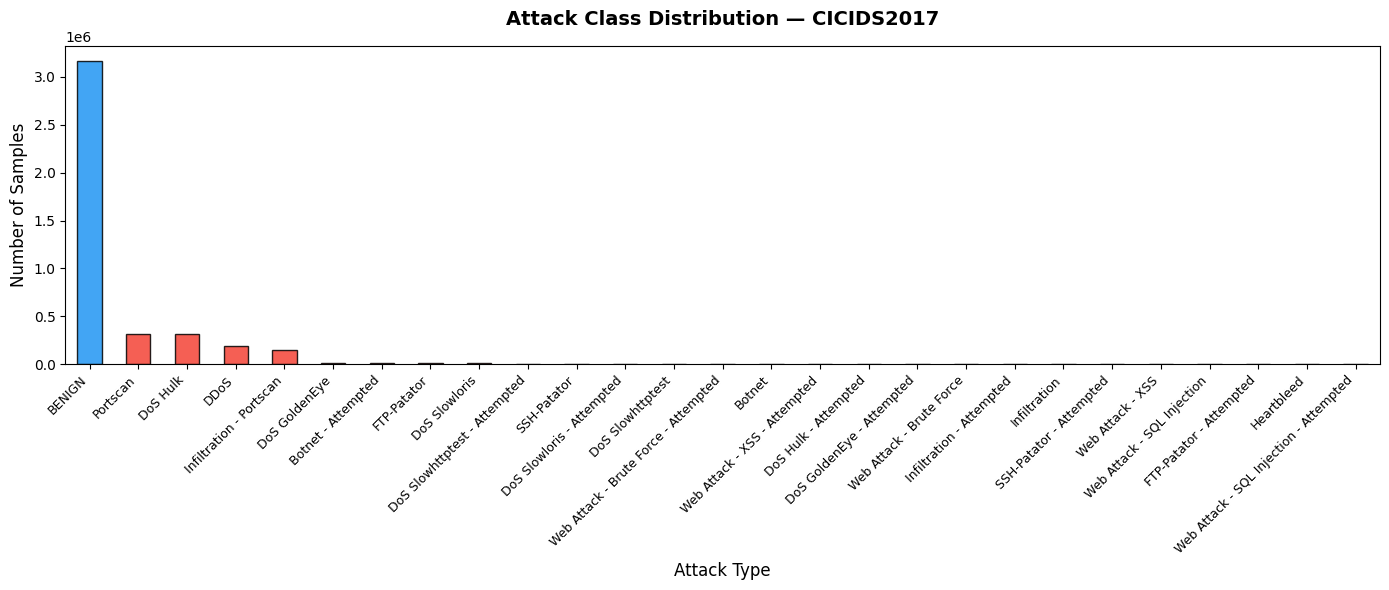

✅ Plot saved!


In [8]:
# CELL 5 — Visualise class distribution
plt.figure(figsize=(14, 6))
colors = ['#2196F3' if x == 'BENIGN' else '#F44336'
          for x in counts.index]

counts.plot(kind='bar',
            color=colors,
            edgecolor='black',
            alpha=0.85)

plt.title('Attack Class Distribution — CICIDS2017',
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Attack Type', fontsize=12)
plt.ylabel('Number of Samples', fontsize=12)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150,
            bbox_inches='tight')
plt.show()
print("✅ Plot saved!")

In [9]:
# CELL 6 — Check data quality
print("DATA QUALITY REPORT:")
print("=" * 45)

# Missing values
null_count = df.isnull().sum().sum()
print(f"Missing values   : {null_count:,}")

# Infinite values
numeric_df = df.select_dtypes(include=np.number)
inf_count = np.isinf(numeric_df).sum().sum()
print(f"Infinite values  : {inf_count:,}")

# Duplicate rows
dup_count = df.duplicated().sum()
print(f"Duplicate rows   : {dup_count:,}")

# Data types
print(f"\nData types:")
print(df.dtypes.value_counts().to_string())

# Show sample of data
print(f"\nFirst 3 rows sample:")
print(df.head(3).to_string())

DATA QUALITY REPORT:
Missing values   : 33,599,536
Infinite values  : 0
Duplicate rows   : 6,331

Data types:
int64      62
float64    40
object      3

First 3 rows sample:
   Src IP dec  Src Port  Dst IP dec  Dst Port  Protocol Timestamp  Flow Duration  Total Fwd Packet  Total Bwd packets  Total Length of Fwd Packet  Total Length of Bwd Packet  Fwd Packet Length Max  Fwd Packet Length Min  Fwd Packet Length Mean  Fwd Packet Length Std  Bwd Packet Length Max  Bwd Packet Length Min  Bwd Packet Length Mean  Bwd Packet Length Std  Flow Bytes/s  Flow Packets/s  Flow IAT Mean  Flow IAT Std  Flow IAT Max  Flow IAT Min  Fwd IAT Total  Fwd IAT Mean  Fwd IAT Std  Fwd IAT Max  Fwd IAT Min  Bwd IAT Total  Bwd IAT Mean  Bwd IAT Std  Bwd IAT Max  Bwd IAT Min  Fwd PSH Flags  Bwd PSH Flags  Fwd URG Flags  Bwd URG Flags  Fwd RST Flags  Bwd RST Flags  Fwd Header Length  Bwd Header Length  Fwd Packets/s  Bwd Packets/s  Packet Length Min  Packet Length Max  Packet Length Mean  Packet Length Std  Packet 

In [10]:
# CELL 7 — Feature statistics
numeric_cols = df.select_dtypes(include=np.number).columns
print(f"Numeric features  : {len(numeric_cols)}")
print(f"Non-numeric cols  : {df.shape[1] - len(numeric_cols)}")

# Basic stats of numeric columns
stats = df[numeric_cols].describe().T
print(f"\nTop 10 features by variance:")
top_var = stats['std'].nlargest(10)
print(top_var.to_string())

Numeric features  : 102
Non-numeric cols  : 3

Top 10 features by variance:
Local_14      1.486594e+09
Local_13      1.321025e+09
Local_1       1.223433e+09
Dst IP dec    8.274988e+08
Local_9       8.268816e+08
Local_8       6.279305e+08
Local_7       6.209266e+08
Local_11      6.063464e+08
Local_6       5.991199e+08
Local_10      5.924998e+08


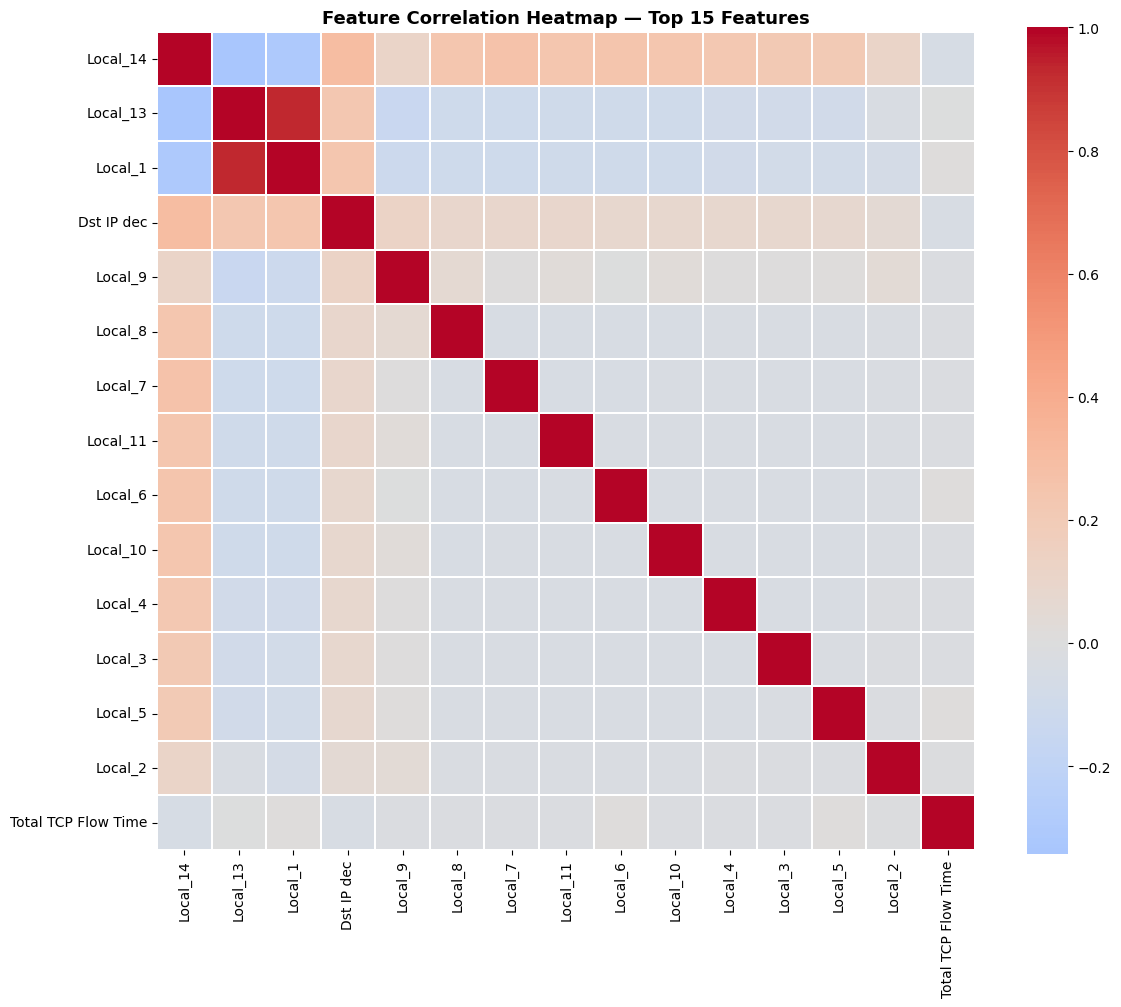

✅ Correlation heatmap saved!


In [11]:
# CELL 8 — Correlation heatmap (top 15 features)
# Select top 15 most variable features
top_features = df[numeric_cols].std()\
                               .nlargest(15).index.tolist()

corr = df[top_features].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr,
            cmap='coolwarm',
            center=0,
            annot=False,
            linewidths=0.3,
            square=True)

plt.title('Feature Correlation Heatmap — Top 15 Features',
          fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("✅ Correlation heatmap saved!")

In [13]:
# CELL 9 — Save EDA summary as JSON
summary = {
    'total_samples'    : int(len(df)),
    'total_features'   : int(df.shape[1]),
    'n_classes'        : int(df[label_col].nunique()),
    'class_names'      : df[label_col].unique().tolist(),
    'label_column'     : label_col,
    'null_count'       : int(null_count),
    'inf_count'        : int(inf_count),
    'duplicate_count'  : int(dup_count),
    'numeric_features' : int(len(numeric_cols)),
    'files_loaded'     : 10
}

with open('eda_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("✅ EDA Summary:")
print("=" * 40)
for k, v in summary.items():
    print(f"  {k:22s} : {v}")

print("\n🎉 DAY 1 EDA COMPLETE!")
print("Ready for Day 2 — Preprocessing!")


✅ EDA Summary:
  total_samples          : 4199942
  total_features         : 105
  n_classes              : 27
  class_names            : ['BENIGN', 'Botnet - Attempted', 'Botnet', 'Portscan', 'DDoS', 'Web Attack - Brute Force - Attempted', 'Web Attack - Brute Force', 'Infiltration - Attempted', 'Infiltration', 'Infiltration - Portscan', 'Web Attack - XSS - Attempted', 'Web Attack - XSS', 'Web Attack - SQL Injection - Attempted', 'Web Attack - SQL Injection', 'FTP-Patator - Attempted', 'FTP-Patator', 'SSH-Patator', 'SSH-Patator - Attempted', 'DoS Slowloris', 'DoS Slowloris - Attempted', 'DoS Slowhttptest', 'DoS Slowhttptest - Attempted', 'DoS Hulk', 'DoS Hulk - Attempted', 'DoS GoldenEye', 'Heartbleed', 'DoS GoldenEye - Attempted']
  label_column           : Label
  null_count             : 33599536
  inf_count              : 0
  duplicate_count        : 6331
  numeric_features       : 102
  files_loaded           : 10

🎉 DAY 1 EDA COMPLETE!
Ready for Day 2 — Preprocessing!
